# ノイズ除去で、異常検知は良くなるか？ — 第2回の実験を読む

[Zenn第1回](https://zenn.dev/kasahart/articles/kasahart-20260919-dcase2026-asd-01)の続きです。記事では、**同じ検知器に渡す音だけを変えたとき、成績がどう変わるか**を比較しました。このNotebookでは結果の表を読み、実録音の図で2種類の引き算の違いを確かめます。

**GitHubで読むだけなら、実行やインストールは不要です。** 保存済みの表と図を、そのまま下へ読んでください。音声・重みのダウンロードも不要です。ローカルでの手動試聴は3節で案内します。試聴ボタンはローカル実行時に表示します。

## 1. 4条件で何を変えたか

| 記号 | 記事での呼び方 | 検知器に渡す音 |
|---|---|---|
| B0 | 近いマイクのみ | 近いマイクの録音をそのまま使う。比較の基準 |
| B1 | 遠いマイクのみ | 遠いマイクの録音をそのまま使う |
| W1 | 線形減算（複素減算） | 遠い側の大きさと位相を調整して、近い側から引く |
| SS | スペクトル減算 | 周波数ごとの大きさを引き、近い側の位相で波形へ戻す |

どの条件もBEATs・RDP・BEAM・VarMinの設定は共通です。**正常音の比較基準も、それぞれの条件で作り直します。**

*次のセルは表示の準備コードです。読むだけなら飛ばして、結果の表へ進んでください。*

In [1]:
%matplotlib inline
import hashlib, json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import wandas as wd
from asd_min.waveform import condition_audio
ROOT = Path.cwd() if (Path.cwd() / "results").exists() else Path.cwd().parent
ENABLE_AUDIO = False  # Trueにすると手動再生ボタンを表示。自動再生しません。
plt.rcParams["font.family"] = "Noto Sans CJK JP"


## 2. 結果の読み方 — W1は上がり、SSは総合では上がらなかった

次の表の「総合スコア」は記事の検証スコアと同じものです。高いほど良く、「B0との差」は近いマイクのみを基準にした**ポイント差**です。

In [2]:
summary = pd.read_csv(ROOT/"results/02-summary.csv").set_index("condition").reindex(["b0","b1","w1","ss"])
CONDITION_NAMES = {"b0":"B0：近いマイク", "b1":"B1：遠いマイク", "w1":"W1：線形減算", "ss":"SS：スペクトル減算"}
totals = summary["official_score"]*100
reading_table = pd.DataFrame({"条件":[CONDITION_NAMES[c] for c in summary.index],
                              "総合スコア":totals.to_numpy(),
                              "B0との差（ポイント）":(totals-totals.loc["b0"]).to_numpy()})
display(reading_table.round(3))

,条件,総合スコア,B0との差（ポイント）
0,B0：近いマイク,62.841,0.000
1,B1：遠いマイク,58.362,-4.479
2,W1：線形減算,66.835,3.994
3,SS：スペクトル減算,62.325,-0.516


**この比較では、W1はB0より高く、SSは低い結果です。** 遠いマイクを使えば必ず改善するわけではなく、使い方で結果が変わりました。

### 機種ごとの結果も見る

pAUCは、正常音への誤警報を少なく抑えた範囲で、異常を見分ける成績です。表と棒グラフはpAUCを100倍し、0〜100で示しています。グラフの機種名は配布データの英語名です。日本語との対応は表に示します。

condition,B0：近いマイク,B1：遠いマイク,W1：線形減算,SS：スペクトル減算
machine,,,,
集じん機（BlowerDustCollector）,72.000,59.842,73.158,73.474
研磨機（Sander）,51.947,49.263,55.947,52.368
ミシン（SewingMachine）,66.000,59.158,67.105,64.684
電動歯ブラシ（ToothBrush）,50.158,51.368,53.211,49.632
小型ドローン（ToyDrone）,57.842,57.105,62.316,57.579


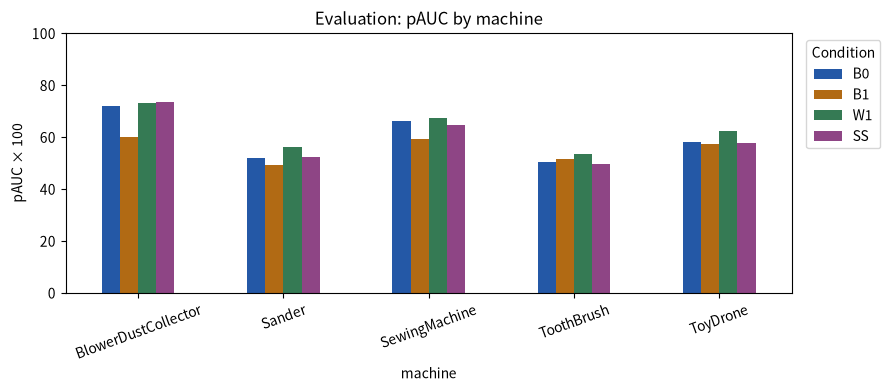

In [3]:
by_machine = pd.read_csv(ROOT/"results/02-by-machine.csv")
pauc = by_machine.pivot(index="machine", columns="condition", values="pauc").reindex(columns=["b0","b1","w1","ss"])*100
MACHINE_NAMES = {"BlowerDustCollector":"集じん機（BlowerDustCollector）", "Sander":"研磨機（Sander）",
                 "SewingMachine":"ミシン（SewingMachine）", "ToothBrush":"電動歯ブラシ（ToothBrush）", "ToyDrone":"小型ドローン（ToyDrone）"}
display(pauc.rename(index=MACHINE_NAMES, columns=CONDITION_NAMES).round(3))
ax=pauc.rename(columns={c:c.upper() for c in pauc.columns}).plot.bar(figsize=(9,4), rot=20,
    color=["#2458a6","#b16a14","#357a54","#8e4585"])
ax.set(title="Evaluation: pAUC by machine", ylabel="pAUC × 100", ylim=(0,100))
ax.legend(title="Condition", loc="upper left", bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()

## 3. 同じ実録音で波形を比較する

電動歯ブラシの正常録音を使います。B0は近接マイク（ch 0）、B1は遠方マイク（ch 1）。W1は遠方の複素スペクトルを合わせて近接から引き、SSはスペクトルの大きさを引きます。処理は実験と同じ関数です。

ファイル名順に正常source training録音3件（0000〜0002）を確認し、先頭の0000を使います。W1の残留量や検知成績で選んでいません。対象録音の全6秒を処理し、Wandasの`describe`で波形・スペクトログラム・周波数スペクトルを表示します。波形とスペクトログラムの時間軸は0〜6秒です。振幅軸・周波数軸・スペクトルのレベル軸・色範囲は4条件共通です。手動試聴では4条件すべて全長6秒の音声を再生します。各音声を個別に正規化しません。

保存図はそのまま読めます。試聴・再描画には[公式データ](https://zenodo.org/records/20151556)を取得し、`ASD_DATA_ROOT`を`ToothBrush`を含むディレクトリに指定します。この波形比較にモデルの重みは不要です。音声は同梱していません。

**出典・図の利用条件：** Nishidaほか、DCASE 2026 Challenge Task 2 Additional Training Dataset v1。以下の実録音由来の図は **CC BY-NC-SA 4.0**です。[帰属と加工内容](DATA_ATTRIBUTION.md)を参照してください。


In [4]:
example = json.loads((ROOT / "configs/02-recording-example.json").read_text())
DATA_ROOT = Path(os.environ.get("ASD_DATA_ROOT", ROOT / "eval_data/raw"))
path = DATA_ROOT / example["path"]
assert hashlib.sha256(path.read_bytes()).hexdigest() == example["sha256"]
audio = wd.read(path)
assert audio.sampling_rate == 16000 and audio.data.shape == (2, 96000)
wave = audio.data.astype(np.float32)
recordings = {
    c: wd.from_numpy(condition_audio(wave, c), sampling_rate=audio.sampling_rate,
                     ch_labels=[c.upper()], ch_units="amplitude")
    for c in ("b0", "b1", "w1", "ss")
}
DESCRIBE = dict(normalize=False, is_close=ENABLE_AUDIO, xlim=(0, 6),
                fmax=8000, ylim=(0, 8000), vmin=-100, vmax=0,
                waveform={"ylim": (-.5, .5)}, spectral={"xlim": (-100, 0)})
CREDIT = "Nishida et al. · doi:10.5281/zenodo.20151556 · CC BY-NC-SA 4.0"


### B0：近接マイク

処理前の基準です。機械音と環境音が混ざった録音を、そのまま検知器へ渡します。

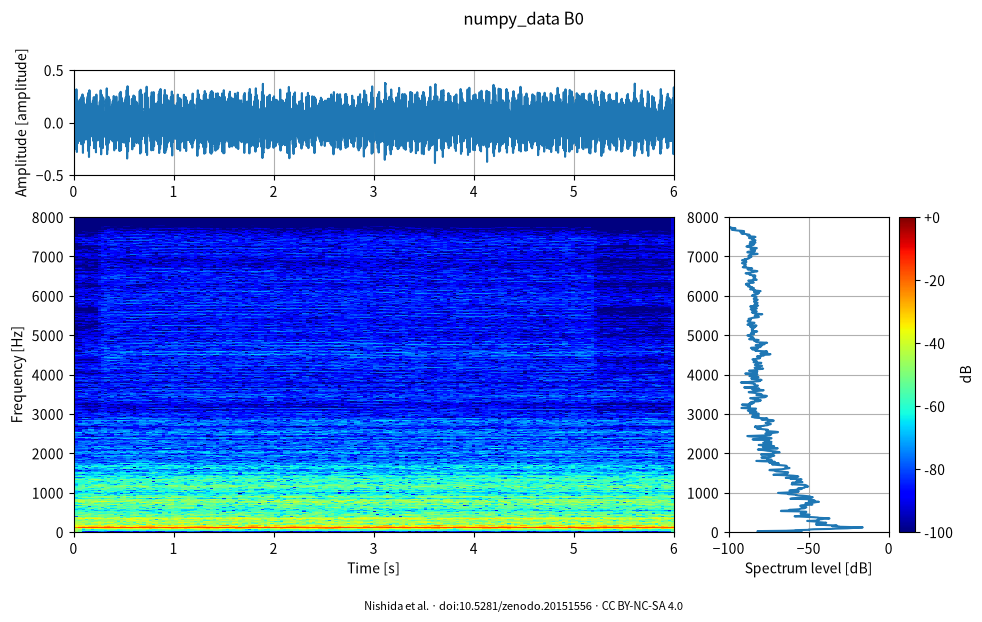

In [5]:
figures = recordings["b0"].describe(**DESCRIBE)
for fig in figures or []:
    fig.text(.5, -.02, CREDIT, ha="center", fontsize=8)
    display(fig)
    plt.close(fig)


### B1：遠方マイク

同時刻の遠方側です。近接側との波形・周波数成分の違いを見ます。遠方にも機械音が入るため、雑音だけの参照ではありません。

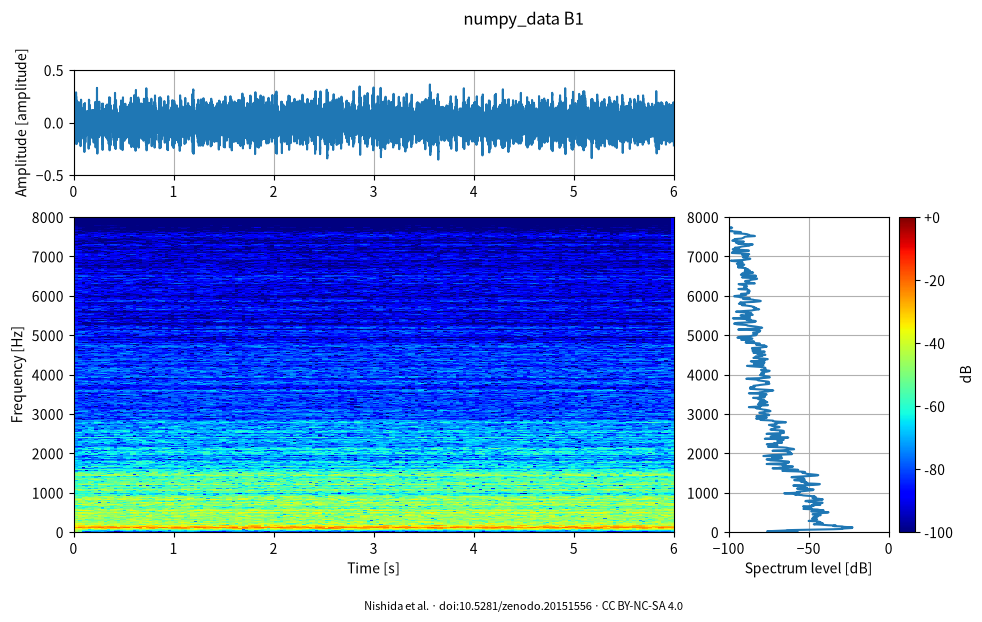

In [6]:
figures = recordings["b1"].describe(**DESCRIBE)
for fig in figures or []:
    fig.text(.5, -.02, CREDIT, ha="center", fontsize=8)
    display(fig)
    plt.close(fig)


### W1：線形減算（複素減算）

対象録音の全6秒から周波数ごとの複素係数を求め、遠方に共通する成分を近接から引いた出力です。B0と同じ振幅軸で、残った波形と周波数成分を確認できます。

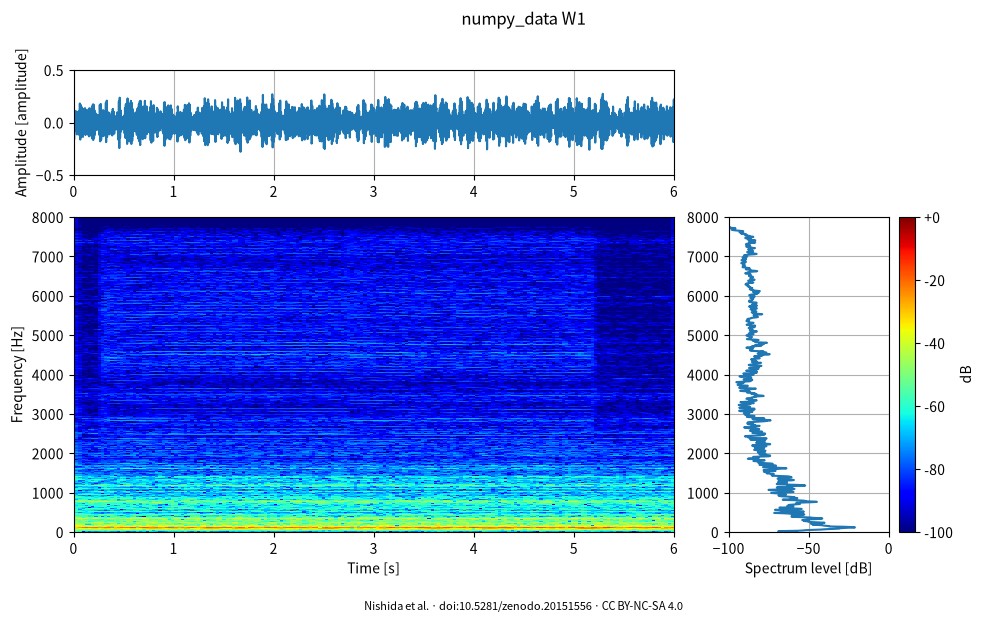

In [7]:
figures = recordings["w1"].describe(**DESCRIBE)
for fig in figures or []:
    fig.text(.5, -.02, CREDIT, ha="center", fontsize=8)
    display(fig)
    plt.close(fig)


### SS：スペクトル減算

遠方の大きさを近接から引き、近接の位相を使った出力です。W1とは引き方が異なります。両者を同じ表示条件で比べます。

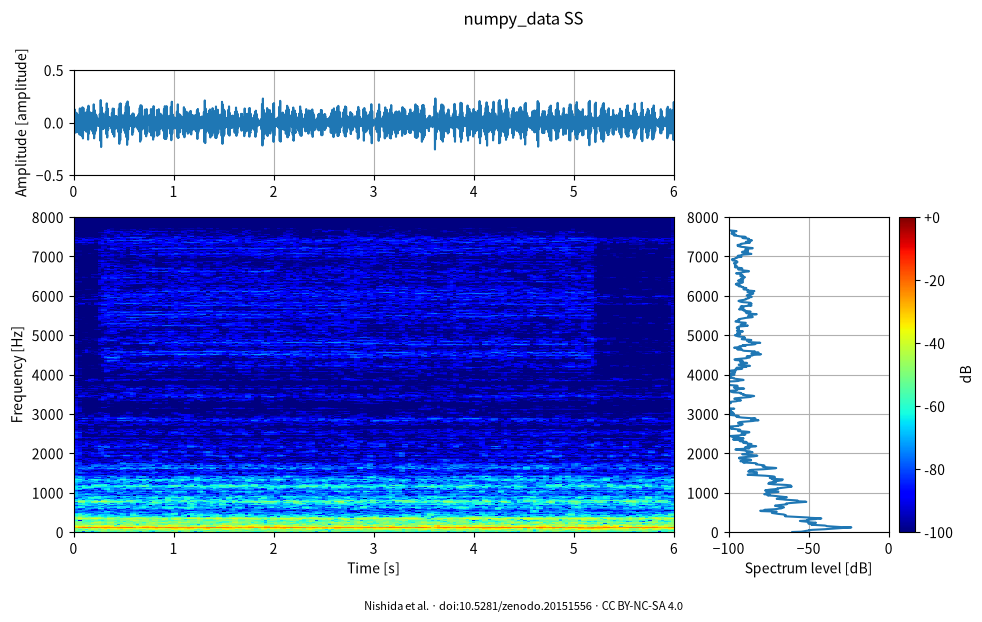

In [8]:
figures = recordings["ss"].describe(**DESCRIBE)
for fig in figures or []:
    fig.text(.5, -.02, CREDIT, ha="center", fontsize=8)
    display(fig)
    plt.close(fig)


## 4. 図と検知スコアの読み分け

この録音には機械音だけの正解波形がありません。振幅や帯域の変化は観察できますが、機械音の保持率や雑音除去の成功率には換算できません。上の検知スコアはデータ集合全体の評価で、この1録音の見た目や聞こえ方の順位ではありません。

表示用STFTは可視化ライブラリWandasの処理です。W1・SSの計算用STFTは実験実装に固定してあり、表示から再計算しません。各条件で正常参照も作り直して比較しています。

[波形処理の説明](../src/asd_min/waveform.md) / [必要入力](../docs/02-inputs.md) / [検証範囲](../docs/02-validation.md)
